## Analysis of the splits of the dataset

Extract the data from QCArchive

In [44]:
from rdkit import Chem, DataStructs
from rdkit import RDLogger
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd
import math
from rdkit import Chem, DataStructs
from rdkit.DataStructs.cDataStructs import BulkTanimotoSimilarity
import matplotlib.pyplot as plt
from typing import List, Sequence, Tuple
import deepchem as dc



from rdkit.DataStructs.cDataStructs import BulkTanimotoSimilarity

RDLogger.DisableLog('rdApp.*')


def smiles_to_fps(smiles, radius=2, nbits=1024):
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits, useChirality=True)
           for m in mols if m is not None]
    return fps

def read_smiles_from_csv(file_path, smiles_column='smiles'):
    import pandas as pd
    df = pd.read_csv(file_path)
    smiles = df[smiles_column].tolist()
    return smiles

def read_smiles_from_json(file_path):
    import json
    with open(file_path, 'r') as f:
        data = json.load(f)
    data = data.keys()
    print(data)
    smiles = [entry for entry in data]
    return smiles

# TEST_SMILES_CSV = 'test_smiles.csv'
# TRAIN_SMILES_CSV = 'training_smiles.csv'
# VAL_SMILES_CSV = 'validation_smiles.csv'
TEST_SMILES_JSON = 'maxmin-test2.json'
TRAIN_SMILES_JSON = 'maxmin-train2.json'
VAL_SMILES_JSON = 'maxmin-valid2.json'


In [45]:
# smiles_in_train = list(set(read_smiles_from_json(TRAIN_SMILES_CSV)))
# smiles_in_test = list(set(read_smiles_from_json(TEST_SMILES_CSV)))
# smiles_in_val = list(set(read_smiles_from_json(VAL_SMILES_CSV)))
smiles_in_train = list(set(read_smiles_from_json(TRAIN_SMILES_JSON)))
smiles_in_test = list(set(read_smiles_from_json(TEST_SMILES_JSON)))
smiles_in_val = list(set(read_smiles_from_json(VAL_SMILES_JSON)))


print(f'total length of dataset splits: {len(smiles_in_train)+len(smiles_in_test)+len(smiles_in_val)}')

fps_a = smiles_to_fps(smiles_in_train)
fps_b = smiles_to_fps(smiles_in_test)

arr_a = np.asarray([np.frombuffer(fp.ToBitString().encode('utf-8'), 'S1') == b'1' for fp in fps_a])
arr_b = np.asarray([np.frombuffer(fp.ToBitString().encode('utf-8'), 'S1') == b'1' for fp in fps_b])

max_sim, min_sim = 0, 1
max_pair, min_pair = None, None

same_pairs = []

for i, fp in enumerate(fps_a):
    sims = BulkTanimotoSimilarity(fp, fps_b)
    j_max = np.argmax(sims)
    j_min = np.argmin(sims)
    if sims[j_max] == 1.0:
        same_pairs.append((smiles_in_train[i], smiles_in_test[j_max]))
    if sims[j_max] > max_sim:
        max_sim = sims[j_max]
        max_pair = (smiles_in_train[i], smiles_in_test[j_max])
    if sims[j_min] < min_sim:
        min_sim = sims[j_min]
        min_pair = (smiles_in_train[i], smiles_in_test[j_min])



dict_keys(['[H:1][C:2]1=[N:3][O:4][C:5](=[N:14]1)[C:6]2([C:8]([C:11]2([Br:12])[Br:13])([H:9])[H:10])[H:7]', '[H:1][C:2]1=[N:3][C:4](=[N:17][N:18]1[H:19])[S:5][C:6]([H:7])([H:8])[C:9]2([C:11]([C:14]2([Br:15])[Br:16])([H:12])[H:13])[H:10]', '[H:1][C:2]1=[N:19][N:17]([C:4](=[N:3]1)[S:5][C:6]([H:7])([H:8])[C:9]2([C:11]([C:14]2([Br:15])[Br:16])([H:12])[H:13])[H:10])[H:18]', '[H:1][C:2]1=[N:3][N:4]=[C:5]([N:18]1[H:19])[S:6][C:7]([H:8])([H:9])[C:10]2([C:12]([C:15]2([Br:16])[Br:17])([H:13])[H:14])[H:11]', '[H:12][c:3]1[c:2]2[c:7]([n:6][c:5]([n:4]1)[H:13])[S:8][C:9](=[C:1]2[H:11])[Br:10]', '[H:13][C:1]1=[C:5]([N:4]([C:3]2=[C:2]1[O:12][C:11]3([C:7]2([C:8]([N:9]([C:10]3([H:19])[H:20])[H:18])([H:16])[H:17])[H:15])[H:21])[H:14])[Br:6]', '[H:13][C:1]1=[C:5]([N:4]([C:3]2=[C:2]1[N:9]([C:8]([C:7]2([H:15])[C:10]3([C:11]([C:12]3([H:22])[H:23])([H:20])[H:21])[H:19])([H:16])[H:17])[H:18])[H:14])[Br:6]', '[H:13][C:1]1=[C:5]([O:4][C:3]2=[C:2]1[O:12][C:11]3([C:7]2([C:8]([N:9]([C:10]3([H:18])[H:19])[H:17])([H:

In [46]:
same_pairs[0]

('[H:15][C:4]1([C:3]([C:2]([C:1]([C:8]([C:7]([C:6]([C:5]1([H:17])[H:18])([H:19])[H:20])([H:21])[H:22])([H:23])[H:24])([H:9])[H:10])([H:11])[H:12])([H:13])[H:14])[H:16]',
 '[H:4][C:1]1([C:2]([C:3]1([H:8])[H:9])([H:6])[H:7])[H:5]')

In [47]:
len(same_pairs)

13

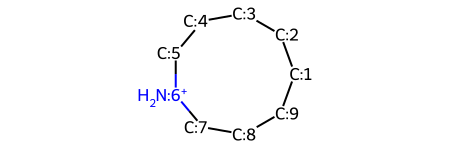

In [58]:
Chem.MolFromSmiles(same_pairs[3][1])

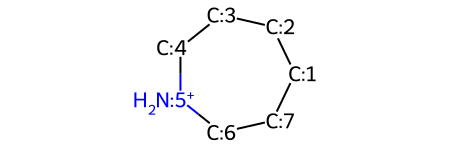

In [59]:
Chem.MolFromSmiles(same_pairs[3][0])

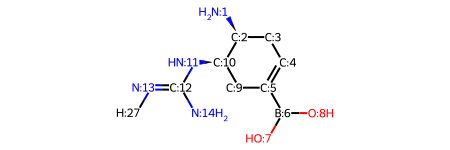

In [30]:
Chem.MolFromSmiles(same_pairs[1][0])

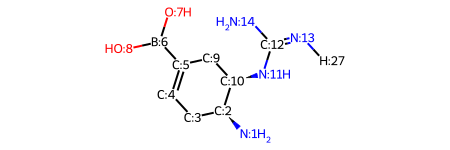

In [28]:
Chem.MolFromSmiles(same_pairs[1][1])

[H:17][C:1](=[O:2])[C@@:3]1([C@@:15]([C@:13]([C@:11]([C@@:5]([O:4]1)([H:19])[O:6][Si:7]([C:8]([H:20])([H:21])[H:22])([O:9][H:23])[O:10][H:24])([H:25])[O:12][H:26])([H:27])[O:14][H:28])([H:29])[O:16][H:30])[H:18]


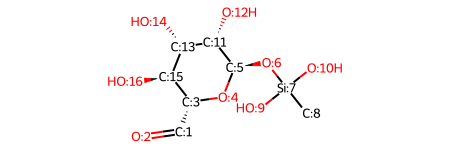

In [34]:
print(same_pairs[2][0])
Chem.MolFromSmiles(same_pairs[2][0])

[H:17][C:1](=[O:2])[C@:3]1([C@@:15]([C@:13]([C@:11]([C@:5]([O:4]1)([H:19])[O:6][Si:7]([C:8]([H:20])([H:21])[H:22])([O:9][H:23])[O:10][H:24])([H:25])[O:12][H:26])([H:27])[O:14][H:28])([H:29])[O:16][H:30])[H:18]


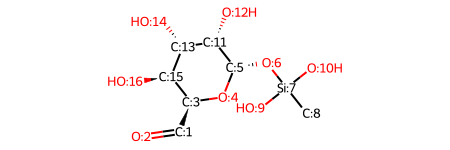

In [35]:
print(same_pairs[2][1])
Chem.MolFromSmiles(same_pairs[2][1])

In [16]:
len(smiles_in_test)

10123

In [17]:
# Deduplicate test set
smiles_in_test_dedup = [s for s in smiles_in_test if s not in [p[1] for p in same_pairs]]
len(smiles_in_test_dedup)

with open('duplicated_smiles.csv', 'w') as f:
    f.write('train_smiles,test_smiles\n')
    for train_s, test_s in same_pairs:
        f.write(f'{train_s},{test_s}\n')

Calculate the max similarity each molecule in the test set to any molecule in the train set

In [18]:


def smiles_to_fps(smiles: Sequence[str], radius=2, nbits=2048):
    fps, valid_idx = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        fps.append(AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits))
        valid_idx.append(i)
    return fps, valid_idx

def test_to_train_similarity_analysis_with_filter(
    train_smiles: Sequence[str],
    test_smiles: Sequence[str],
    radius: int = 2,
    nbits: int = 2048,
    batch_size: int = 1024,
    threshold: float = 0.7,
    csv_path: str = "similar_pairs.csv",
    plot: bool = True,
):
    """
    For each test molecule:
      - Find its most similar training molecule
      - Record any with similarity > threshold in a CSV
    """
    fps_train, kept_train = smiles_to_fps(train_smiles, radius, nbits)
    fps_test, kept_test   = smiles_to_fps(test_smiles,  radius, nbits)

    max_sims = np.zeros(len(fps_test), dtype=np.float32)
    best_train_idx = np.zeros(len(fps_test), dtype=int)
    high_pairs = []

    for i, fp_test in enumerate(fps_test):
        sims = np.asarray(BulkTanimotoSimilarity(fp_test, fps_train), dtype=np.float32)
        j_max = int(np.argmax(sims))
        sim_max = float(sims[j_max])

        if sim_max > threshold:
            # Record high-similarity pair
            # Don't add similar molecules to summary stats
            high_pairs.append({
                "similarity": sim_max,
                "test_idx": kept_test[i],
                "train_idx": kept_train[j_max],
                "test_smiles": test_smiles[kept_test[i]],
                "train_smiles": train_smiles[kept_train[j_max]],
            })
        else:
            max_sims[i] = sim_max
            best_train_idx[i] = j_max
    #drop the zeros
    max_sims = max_sims[max_sims > 0]

    # Compute summary stats
    mean = float(max_sims.mean())
    std = float(max_sims.std())
    s_min = float(max_sims.min())
    s_max = float(max_sims.max())
    stats = {"mean": mean, "std": std, "min": s_min, "max": s_max}

    # Find extremes
    i_most_sim = int(np.argmax(max_sims))
    i_least_sim = int(np.argmin(max_sims))

    most_sim_pair = {
        "similarity": float(max_sims[i_most_sim]),
        "test_idx": kept_test[i_most_sim],
        "train_idx": kept_train[best_train_idx[i_most_sim]],
        "test_smiles": test_smiles[kept_test[i_most_sim]],
        "train_smiles": train_smiles[kept_train[best_train_idx[i_most_sim]]],
    }

    least_sim_pair = {
        "similarity": float(max_sims[i_least_sim]),
        "test_idx": kept_test[i_least_sim],
        "train_idx": kept_train[best_train_idx[i_least_sim]],
        "test_smiles": test_smiles[kept_test[i_least_sim]],
        "train_smiles": train_smiles[kept_train[best_train_idx[i_least_sim]]],
    }

    # Save high-similarity pairs to CSV
    if high_pairs:
        df = pd.DataFrame(high_pairs)
        df.sort_values("similarity", ascending=False, inplace=True)
        df.to_csv(csv_path, index=False)
        print(f"Saved {len(df)} pairs with similarity > {threshold} to '{csv_path}'")
    else:
        print(f"No pairs with similarity > {threshold}")

    if plot:
        plt.figure(figsize=(7,4))
        plt.hist(max_sims, bins=50, edgecolor="black")
        plt.xlabel("Tanimoto Similarity")
        plt.ylabel("Number of test molecules")
        # plt.title("Distribution of nearest-train Tanimoto similarities")
        plt.tight_layout()
        plt.savefig("test_to_train_maxsim_histogram.png", dpi=300)
        plt.show()

    return max_sims, stats, most_sim_pair, least_sim_pair


💾 Saved 603 pairs with similarity > 0.7 to 'similar_pairs.csv'


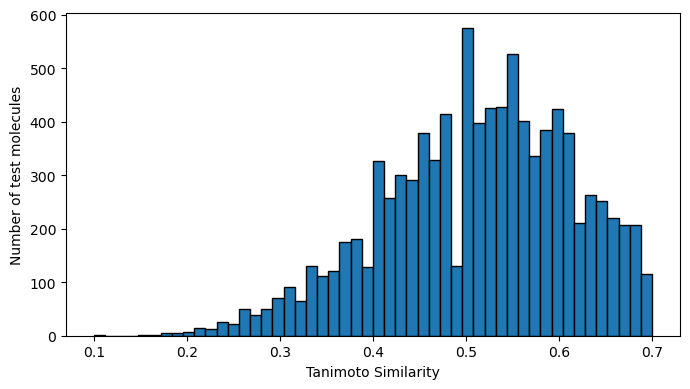

{'mean': 0.5116866827011108, 'std': 0.10161390900611877, 'min': 0.10000000149011612, 'max': 0.699999988079071}


In [19]:

smiles_in_test
fps_train = smiles_to_fps(smiles_in_train, radius=2, nbits=2048)
fps_test  = smiles_to_fps(smiles_in_test_dedup,     radius=2, nbits=2048)

hist, stats, most_sim_pair, least_sim_pair = test_to_train_similarity_analysis_with_filter(
    smiles_in_train, smiles_in_test_dedup, batch_size=2048, plot=True
)

print(stats)


In [20]:
print(most_sim_pair)

{'similarity': 0.699999988079071, 'test_idx': 148, 'train_idx': 21978, 'test_smiles': '[H:12][C:4](=[N+:3]([H:11])[C:2]([H:9])([H:10])[C:1]([H:7])([H:8])[N:6]([H:15])[H:16])[N:5]([H:13])[H:14]', 'train_smiles': '[H:18][C:6](=[N+:5]([H:17])[C:4]([H:15])([H:16])[C:3]([H:13])([H:14])[C:2]([H:11])([H:12])[C:1]([H:8])([H:9])[H:10])[N:7]([H:19])[H:20]'}


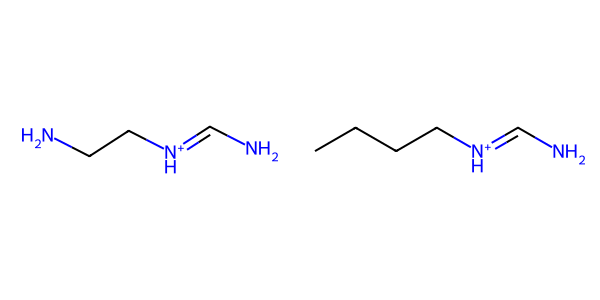

In [21]:
top_pairs_list = []
top_pairs_list.append(Chem.MolFromSmiles(most_sim_pair['test_smiles']))
top_pairs_list.append(Chem.MolFromSmiles(most_sim_pair['train_smiles']))

for mol in top_pairs_list:
    for atom in mol.GetAtoms():
        if atom.HasProp('molAtomMapNumber'):
            atom.ClearProp('molAtomMapNumber')
            
Chem.Draw.MolsToGridImage(top_pairs_list, molsPerRow=2, subImgSize=(300,300))

In [22]:
with open('similar_pairs.csv', 'r') as f:
    similar_pairs_content = f.read()

len(similar_pairs_content.splitlines()) - 1  + len(same_pairs)


731